<a href="https://colab.research.google.com/github/Hany-Kim/ArtificialNN_kosa/blob/main/01_Langgraph_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LangGraph 기초 - Hello World

## 환경 설정

### Package 설치

In [2]:
!pip install --pre -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.0.10
    Uninstalling langgraph-1.0.10:
      Successfully uninstalled langgraph-1.0.10
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.1 which is incompatible.


## Langgraph 구조

In [9]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]}) # mock_llm의 state로 들어감. role종류 ('human', 'user', 'ai', 'assistant', 'function', 'tool', 'system', or 'developer')

{'messages': [HumanMessage(content='bye!', additional_kwargs={}, response_metadata={}, id='5968a7eb-b34f-443f-9e17-538170ece470')]}


{'messages': [HumanMessage(content='bye!', additional_kwargs={}, response_metadata={}, id='5968a7eb-b34f-443f-9e17-538170ece470'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='758501d8-d2f9-43a1-b4c2-711a1797b4a4', tool_calls=[], invalid_tool_calls=[])]}

### Utility Function - showGraph

In [4]:
def showGraph(graph):
    # Show the graph
    from IPython.display import Image, display
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


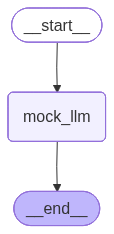

In [5]:
showGraph(graph)